## **Explainability**

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from lime import lime_tabular
import shap

C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Model Setup & Data Loading

In [2]:
# SETUP 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class MentalHealthMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate):
        super(MentalHealthMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# LOAD ARTIFACTS 
artifacts_path = os.path.join('03_classification', 'nn_artifacts')

with open(os.path.join(artifacts_path, 'model_config.json'), 'r') as f:
    config = json.load(f)

scaler = joblib.load(os.path.join(artifacts_path, 'scaler.pkl'))

model = MentalHealthMLP(805, config['hidden_dim'], 5, config['dropout'])
model.load_state_dict(torch.load(os.path.join(artifacts_path, 'mental_health_mlp_weights.pth'), map_location=device))
model.eval().to(device)

# DATA PREPARATION
df_train = pd.read_csv('train_coded.csv')
df_test = pd.read_csv('test_coded.csv')

# Extract feature names (headers)
feature_names = df_train.drop(columns=['label']).columns.tolist()

print(f"Total features retrieved from CSV: {len(feature_names)}")

# Extract raw numerical data (NumPy arrays) for model input
X_train = df_train.drop(columns=['label']).values
X_test = df_test.drop(columns=['label']).values

# Scaling
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


Device: cpu


C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Total features retrieved from CSV: 805


### Lime

Initializing Explainer (using CSV feature names)...

[INFO] Starting analysis on 50 random samples: [7447 2819 2477 6145   81 4711 4985 7618 1496 6485 5162 4034 2800 7009
 1517 2076 5422 7595 6368 2551 2388 5967 6086 1248 1365 3026 3272 2589
 6624 2351 7026 3285  159 6515 7148  739  317 5317  120  522 3163 2060
 3456 6467 3470 7331 4692 7901 6665 7082]

############################################################
RECORD ANALYSIS 1/50 - Dataset Index: 7447
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [+] distilbert_645                           : 0.0215
    [+] distilbert_585                           : 0.0191
    [+] distilbert_286                           : 0.0188
    [+] distilbert_80                            : 0.0165
    [-] distilbert_629                           : -0.0154
    [-] distilbert_632                           : -0.0149
    [+] distilbe

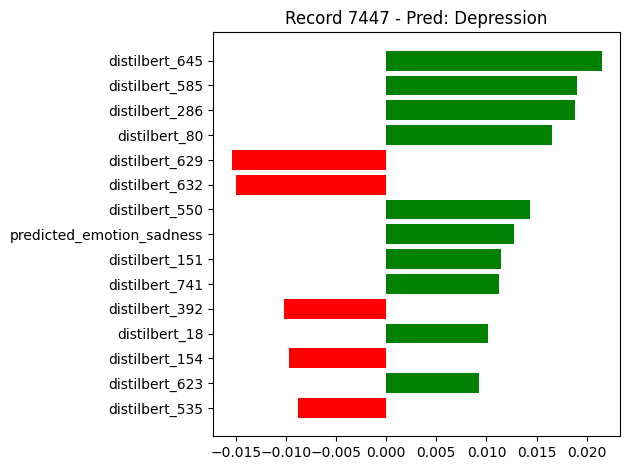


############################################################
RECORD ANALYSIS 2/50 - Dataset Index: 2819
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_155                           : 0.0306
    [-] distilbert_567                           : -0.0243
    [-] distilbert_516                           : -0.0217
    [-] distilbert_83                            : -0.0201
    [+] distilbert_484                           : 0.0189
    [+] distilbert_3                             : 0.0183
    [-] distilbert_93                            : -0.0178
    [+] distilbert_167                           : 0.0174
    [-] distilbert_522                           : -0.0170
    [-] distilbert_703                           : -0.0156
    [+] distilbert_392                           : 0.0143
    [+] distilbert_51                            : 0.0122
    [-] distilbert_66     

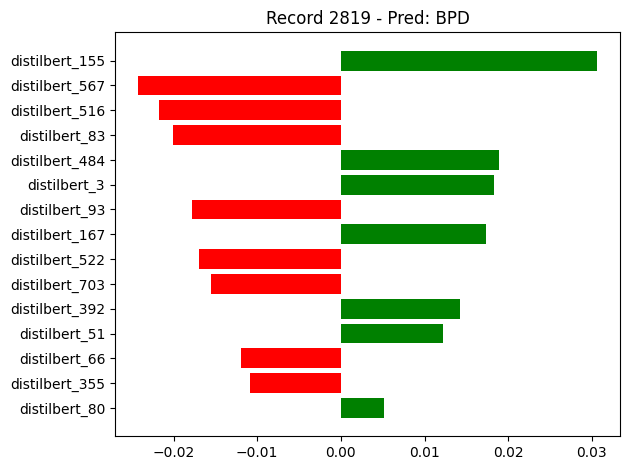


############################################################
RECORD ANALYSIS 3/50 - Dataset Index: 2477
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_155                           : 0.0308
    [+] distilbert_304                           : 0.0237
    [-] distilbert_462                           : -0.0231
    [-] distilbert_703                           : -0.0191
    [+] distilbert_395                           : 0.0184
    [-] distilbert_763                           : -0.0170
    [+] distilbert_348                           : 0.0160
    [-] distilbert_594                           : -0.0150
    [-] distilbert_234                           : -0.0141
    [-] distilbert_643                           : -0.0115
    [+] distilbert_15                            : 0.0106
    [-] distilbert_508                           : -0.0103
    [+] distilbert_39    

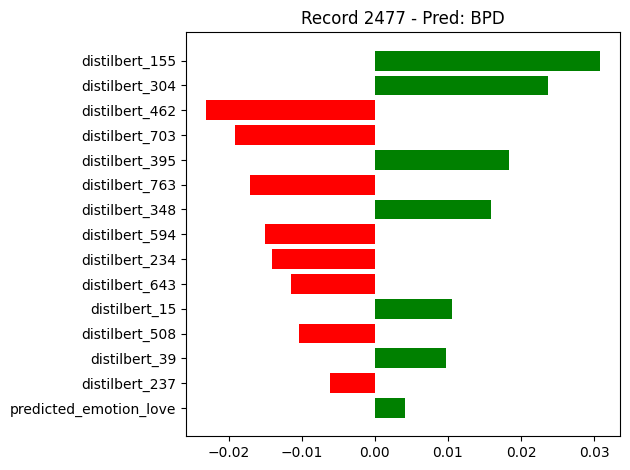


############################################################
RECORD ANALYSIS 4/50 - Dataset Index: 6145
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Anxiety (Class 3)
 -> Top 15 Determinant Features:
    [-] distilbert_681                           : -0.0246
    [-] distilbert_484                           : -0.0201
    [-] distilbert_375                           : -0.0198
    [+] distilbert_685                           : 0.0195
    [+] distilbert_146                           : 0.0189
    [+] distilbert_184                           : 0.0185
    [+] distilbert_651                           : 0.0161
    [+] distilbert_202                           : 0.0151
    [+] distilbert_372                           : 0.0147
    [+] distilbert_643                           : 0.0142
    [-] distilbert_365                           : -0.0134
    [-] distilbert_426                           : -0.0118
    [-] distilbert_86  

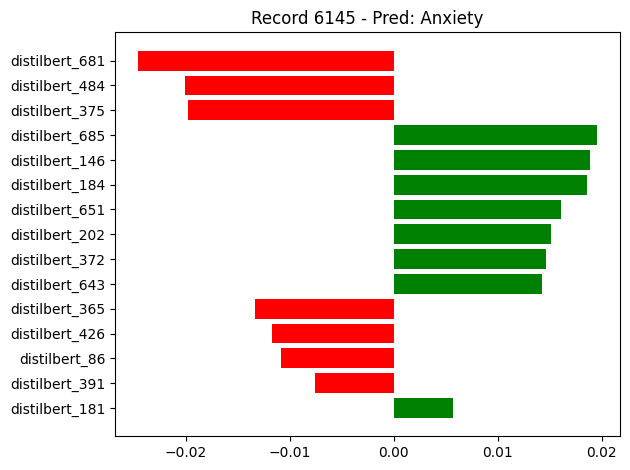


############################################################
RECORD ANALYSIS 5/50 - Dataset Index: 81
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [+] distilbert_286                           : 0.0183
    [-] distilbert_639                           : -0.0177
    [-] distilbert_153                           : -0.0154
    [+] distilbert_585                           : 0.0154
    [+] distilbert_61                            : 0.0151
    [+] predicted_emotion_disappointment         : 0.0143
    [-] distilbert_292                           : -0.0136
    [+] distilbert_400                           : 0.0134
    [+] distilbert_475                           : 0.0113
    [-] distilbert_127                           : -0.0112
    [+] distilbert_164                           : 0.0111
    [+] distilbert_704                           : 0.0105
    [-] distilbert_322 

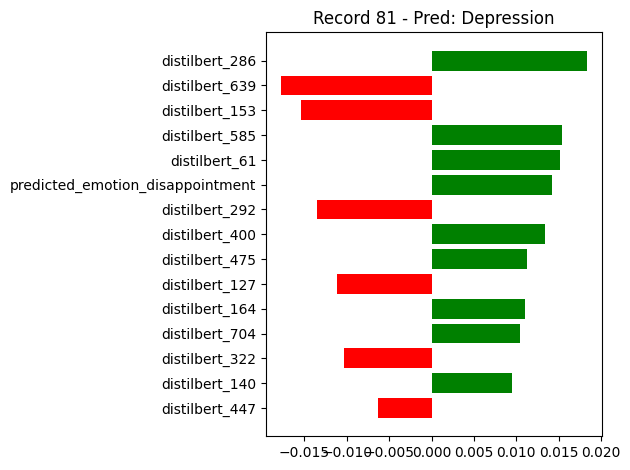


############################################################
RECORD ANALYSIS 6/50 - Dataset Index: 4711
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [-] distilbert_181                           : -0.0241
    [+] distilbert_668                           : 0.0176
    [-] distilbert_250                           : -0.0162
    [+] distilbert_652                           : 0.0150
    [+] toxicity_score_log                       : 0.0118
    [+] distilbert_337                           : 0.0111
    [-] distilbert_607                           : -0.0104
    [-] distilbert_447                           : -0.0085
    [+] distilbert_59                            : 0.0078
    [-] distilbert_551                           : -0.0077
    [-] predicted_emotion_fear                   : -0.0067
    [-] distilbert_278                           : -0.0062
    [-] distilbert

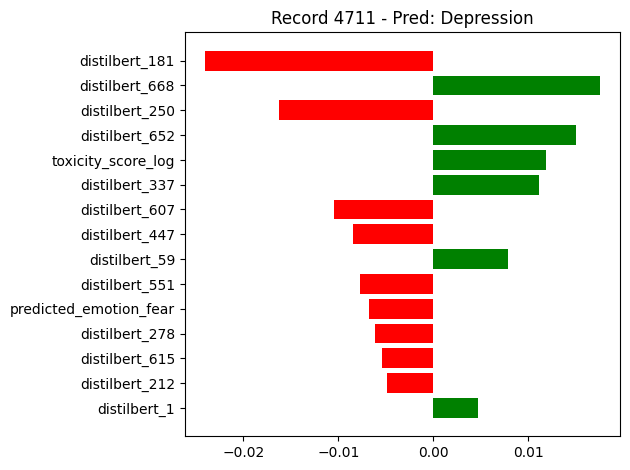


############################################################
RECORD ANALYSIS 7/50 - Dataset Index: 4985
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_155                           : 0.0319
    [+] distilbert_395                           : 0.0241
    [-] distilbert_756                           : -0.0239
    [-] distilbert_83                            : -0.0237
    [+] distilbert_396                           : 0.0231
    [+] distilbert_3                             : 0.0223
    [+] distilbert_167                           : 0.0197
    [+] distilbert_491                           : 0.0187
    [+] distilbert_305                           : 0.0179
    [+] distilbert_498                           : 0.0166
    [+] distilbert_114                           : 0.0152
    [-] distilbert_703                           : -0.0148
    [+] distilbert_591       

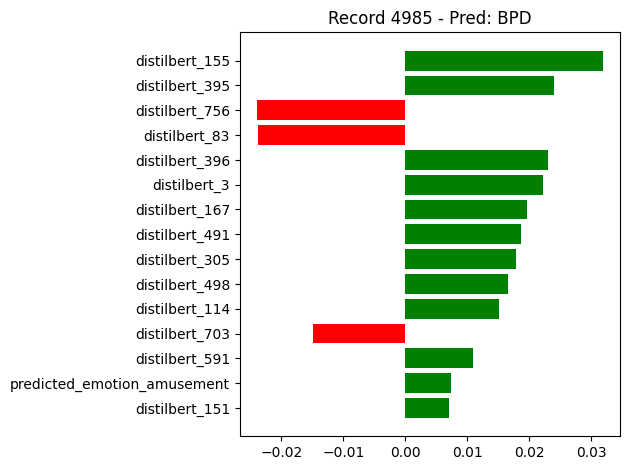


############################################################
RECORD ANALYSIS 8/50 - Dataset Index: 7618
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [+] distilbert_645                           : 0.0200
    [+] distilbert_33                            : 0.0167
    [+] distilbert_400                           : 0.0162
    [+] distilbert_696                           : 0.0158
    [-] distilbert_639                           : -0.0156
    [+] distilbert_21                            : 0.0154
    [-] distilbert_546                           : -0.0126
    [-] distilbert_493                           : -0.0113
    [-] distilbert_703                           : -0.0103
    [+] distilbert_396                           : 0.0100
    [-] distilbert_305                           : -0.0090
    [+] distilbert_275                           : 0.0080
    [-] predicted_em

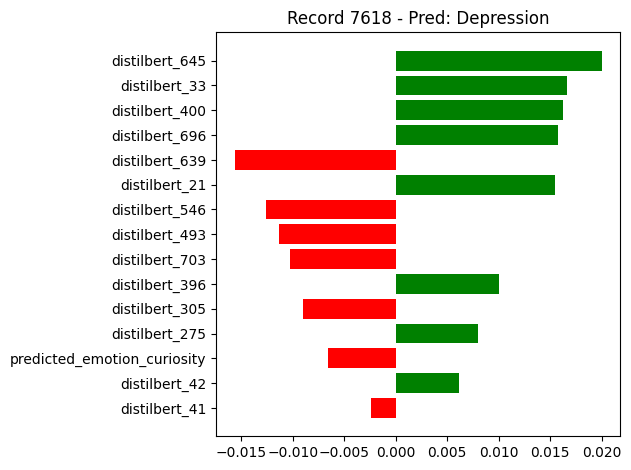


############################################################
RECORD ANALYSIS 9/50 - Dataset Index: 1496
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Anxiety (Class 3)
 -> Top 15 Determinant Features:
    [+] predicted_emotion_nervousness            : 0.0371
    [+] distilbert_234                           : 0.0289
    [+] distilbert_146                           : 0.0230
    [+] distilbert_354                           : 0.0200
    [+] distilbert_612                           : 0.0186
    [-] distilbert_562                           : -0.0158
    [-] distilbert_168                           : -0.0147
    [-] distilbert_765                           : -0.0140
    [+] distilbert_325                           : 0.0136
    [+] distilbert_651                           : 0.0131
    [+] distilbert_442                           : 0.0121
    [+] distilbert_80                            : 0.0113
    [-] distilbert_726   

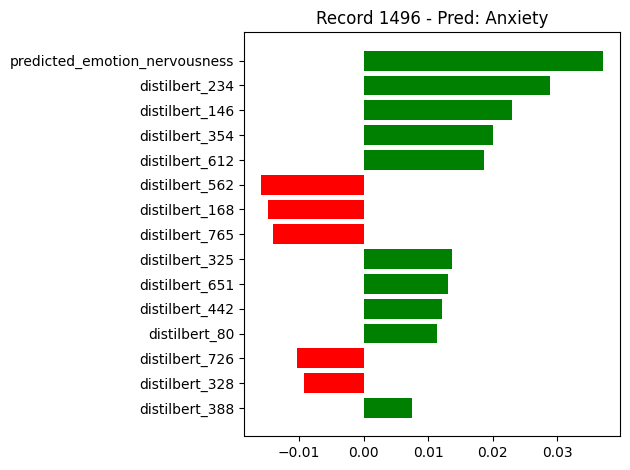


############################################################
RECORD ANALYSIS 10/50 - Dataset Index: 6485
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_629                           : 0.0376
    [+] distilbert_597                           : 0.0298
    [+] distilbert_705                           : 0.0261
    [+] distilbert_128                           : 0.0242
    [+] distilbert_198                           : 0.0219
    [+] distilbert_274                           : 0.0218
    [+] distilbert_638                           : 0.0209
    [-] distilbert_421                           : -0.0207
    [+] distilbert_397                           : 0.0200
    [+] distilbert_105                           : 0.0191
    [+] distilbert_479                           : 0.0173
    [-] distilbert_47                            : -0.0161
    [+] distilbert_674   

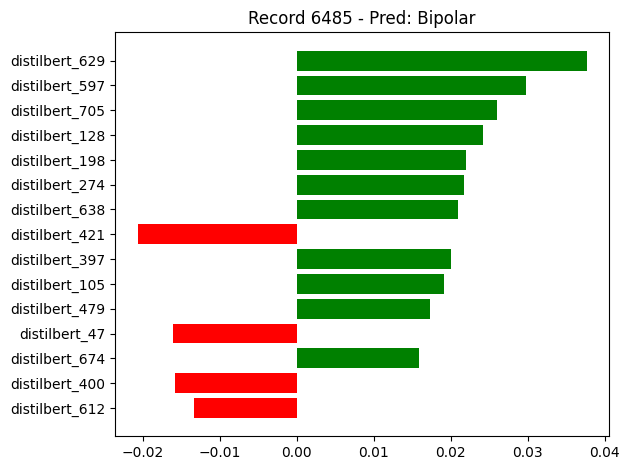


############################################################
RECORD ANALYSIS 11/50 - Dataset Index: 5162
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [+] distilbert_658                           : 0.0315
    [-] distilbert_324                           : -0.0211
    [-] distilbert_108                           : -0.0209
    [-] distilbert_509                           : -0.0196
    [-] distilbert_277                           : -0.0185
    [+] distilbert_127                           : 0.0183
    [+] distilbert_604                           : 0.0183
    [-] distilbert_297                           : -0.0178
    [-] distilbert_80                            : -0.0174
    [+] distilbert_628                           : 0.0163
    [+] distilbert_77                            : 0.0147
    [-] distilbert_166                           : -0.0147
    [-] distil

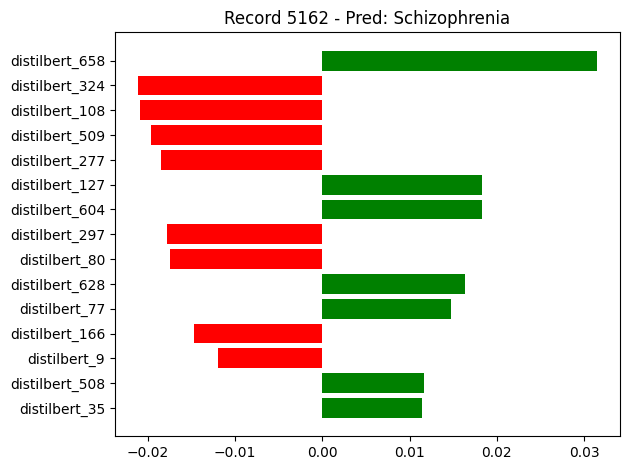


############################################################
RECORD ANALYSIS 12/50 - Dataset Index: 4034
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_691                           : 0.0276
    [+] distilbert_503                           : 0.0262
    [+] distilbert_705                           : 0.0240
    [+] distilbert_206                           : 0.0231
    [+] distilbert_379                           : 0.0230
    [+] distilbert_157                           : 0.0219
    [+] distilbert_355                           : 0.0209
    [+] distilbert_339                           : 0.0192
    [-] distilbert_645                           : -0.0188
    [-] distilbert_558                           : -0.0184
    [-] distilbert_263                           : -0.0171
    [-] distilbert_87                            : -0.0156
    [+] distilbert_153 

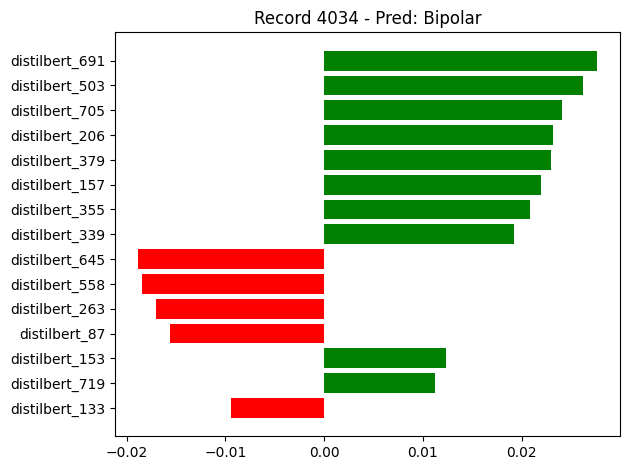


############################################################
RECORD ANALYSIS 13/50 - Dataset Index: 2800
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_510                           : 0.0227
    [-] distilbert_137                           : -0.0213
    [+] distilbert_311                           : 0.0186
    [+] distilbert_396                           : 0.0183
    [-] distilbert_629                           : -0.0177
    [+] distilbert_114                           : 0.0169
    [-] distilbert_430                           : -0.0167
    [-] distilbert_711                           : -0.0166
    [-] distilbert_757                           : -0.0150
    [+] distilbert_609                           : 0.0144
    [-] distilbert_367                           : -0.0138
    [+] distilbert_765                           : 0.0125
    [+] distilbert_151   

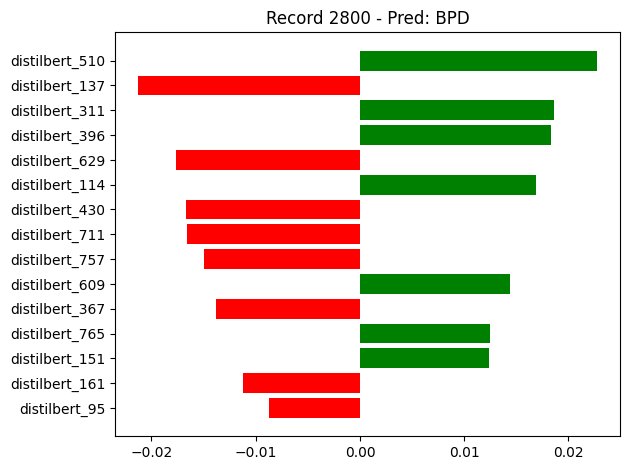


############################################################
RECORD ANALYSIS 14/50 - Dataset Index: 7009
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_597                           : 0.0293
    [+] distilbert_691                           : 0.0268
    [-] distilbert_460                           : -0.0238
    [-] distilbert_1                             : -0.0227
    [-] distilbert_60                            : -0.0225
    [+] distilbert_128                           : 0.0223
    [-] distilbert_421                           : -0.0182
    [-] distilbert_488                           : -0.0166
    [+] distilbert_692                           : 0.0148
    [+] distilbert_426                           : 0.0136
    [-] distilbert_145                           : -0.0129
    [+] distilbert_503                           : 0.0122
    [+] distilbert_32

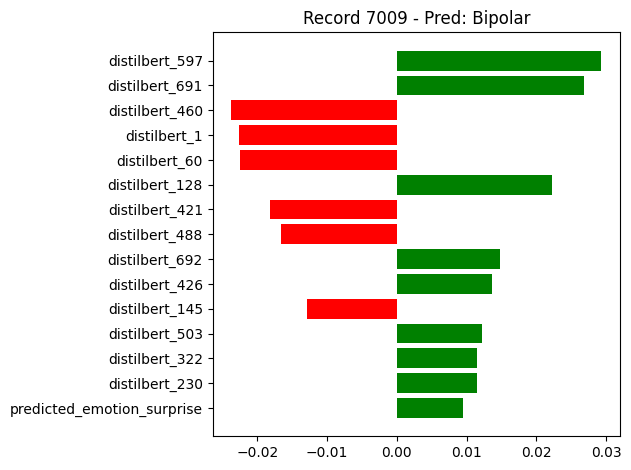


############################################################
RECORD ANALYSIS 15/50 - Dataset Index: 1517
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [-] distilbert_83                            : -0.0306
    [+] distilbert_484                           : 0.0304
    [+] distilbert_477                           : 0.0248
    [+] distilbert_551                           : 0.0237
    [+] distilbert_395                           : 0.0234
    [+] distilbert_292                           : 0.0222
    [+] distilbert_86                            : 0.0201
    [+] distilbert_182                           : 0.0200
    [-] distilbert_552                           : -0.0196
    [+] distilbert_721                           : 0.0165
    [-] distilbert_146                           : -0.0152
    [+] distilbert_465                           : 0.0147
    [-] distilbert_469      

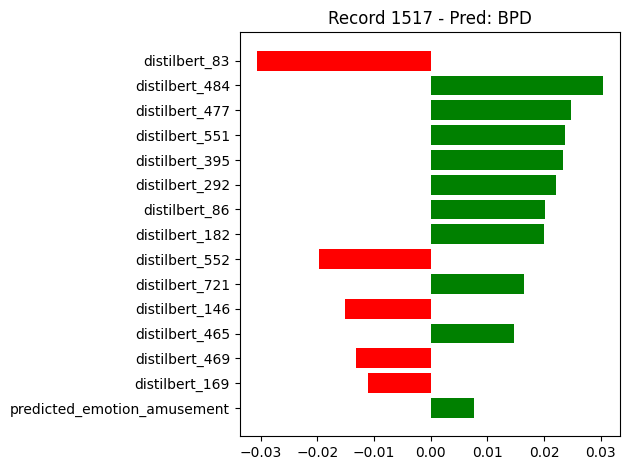


############################################################
RECORD ANALYSIS 16/50 - Dataset Index: 2076
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_551                           : 0.0266
    [+] distilbert_484                           : 0.0206
    [-] distilbert_522                           : -0.0195
    [-] distilbert_757                           : -0.0186
    [-] distilbert_77                            : -0.0182
    [+] distilbert_721                           : 0.0179
    [-] distilbert_202                           : -0.0164
    [-] distilbert_567                           : -0.0152
    [-] distilbert_95                            : -0.0150
    [-] distilbert_629                           : -0.0145
    [-] distilbert_93                            : -0.0136
    [+] distilbert_228                           : 0.0126
    [+] distilbert_218 

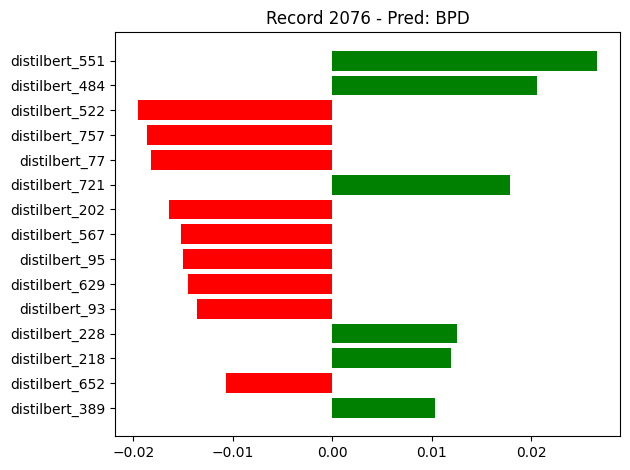


############################################################
RECORD ANALYSIS 17/50 - Dataset Index: 5422
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_206                           : 0.0337
    [-] distilbert_460                           : -0.0277
    [+] distilbert_691                           : 0.0267
    [+] distilbert_9                             : 0.0251
    [+] distilbert_544                           : 0.0250
    [+] distilbert_638                           : 0.0248
    [+] distilbert_629                           : 0.0225
    [-] distilbert_1                             : -0.0214
    [-] distilbert_717                           : -0.0208
    [-] distilbert_58                            : -0.0163
    [-] distilbert_488                           : -0.0160
    [-] distilbert_56                            : -0.0147
    [+] distilbert_55

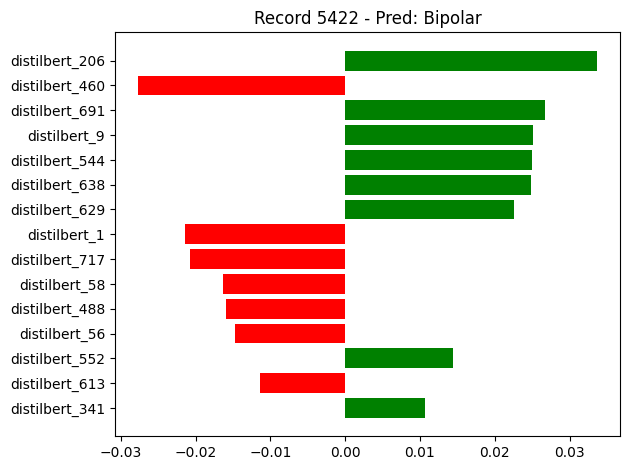


############################################################
RECORD ANALYSIS 18/50 - Dataset Index: 7595
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [+] distilbert_645                           : 0.0258
    [+] distilbert_400                           : 0.0205
    [-] distilbert_705                           : -0.0182
    [+] distilbert_199                           : 0.0153
    [-] distilbert_629                           : -0.0151
    [-] distilbert_153                           : -0.0149
    [+] distilbert_500                           : 0.0143
    [-] distilbert_154                           : -0.0140
    [-] distilbert_432                           : -0.0124
    [-] distilbert_765                           : -0.0123
    [+] distilbert_438                           : 0.0113
    [+] distilbert_579                           : 0.0103
    [+] distilbert

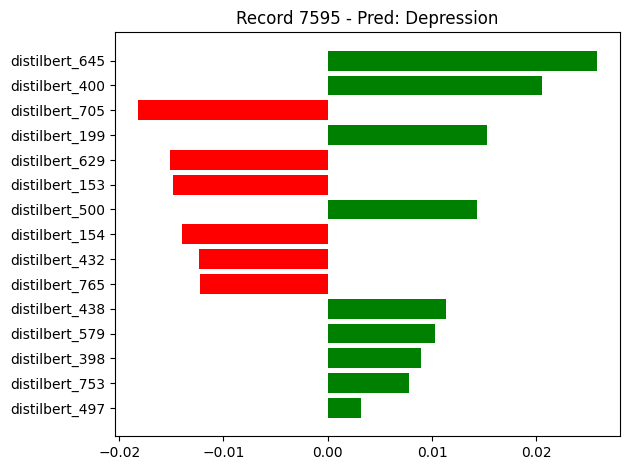


############################################################
RECORD ANALYSIS 19/50 - Dataset Index: 6368
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [+] distilbert_711                           : 0.0232
    [+] distilbert_567                           : 0.0210
    [-] distilbert_448                           : -0.0191
    [+] distilbert_229                           : 0.0188
    [+] distilbert_35                            : 0.0177
    [-] distilbert_324                           : -0.0176
    [+] distilbert_574                           : 0.0168
    [-] distilbert_590                           : -0.0154
    [+] distilbert_621                           : 0.0153
    [-] distilbert_52                            : -0.0152
    [+] distilbert_436                           : 0.0148
    [-] distilbert_226                           : -0.0145
    [+] distilbe

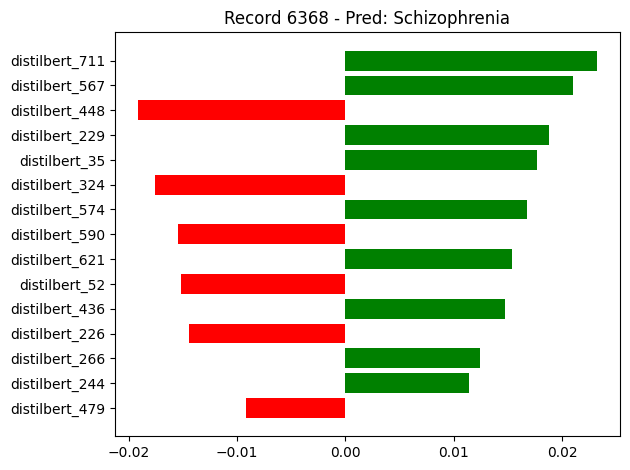


############################################################
RECORD ANALYSIS 20/50 - Dataset Index: 2551
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_484                           : 0.0238
    [+] distilbert_304                           : 0.0223
    [+] distilbert_510                           : 0.0208
    [+] distilbert_58                            : 0.0180
    [+] distilbert_647                           : 0.0180
    [+] distilbert_86                            : 0.0176
    [-] distilbert_90                            : -0.0151
    [+] distilbert_675                           : 0.0150
    [+] distilbert_331                           : 0.0143
    [-] distilbert_604                           : -0.0135
    [-] distilbert_755                           : -0.0121
    [-] distilbert_237                           : -0.0114
    [-] distilbert_77      

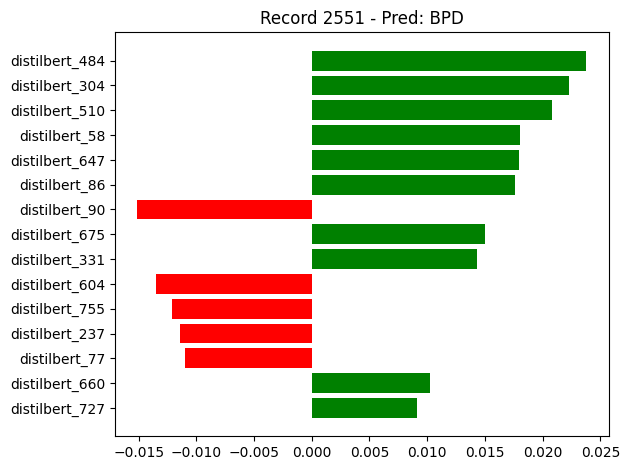


############################################################
RECORD ANALYSIS 21/50 - Dataset Index: 2388
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [-] distilbert_181                           : -0.0191
    [+] distilbert_668                           : 0.0181
    [-] distilbert_153                           : -0.0166
    [+] distilbert_718                           : 0.0163
    [-] distilbert_397                           : -0.0123
    [+] predicted_emotion_sadness                : 0.0121
    [+] distilbert_626                           : 0.0120
    [+] distilbert_80                            : 0.0118
    [-] distilbert_232                           : -0.0099
    [+] distilbert_704                           : 0.0092
    [+] distilbert_25                            : 0.0090
    [-] distilbert_700                           : -0.0083
    [-] distilbert_

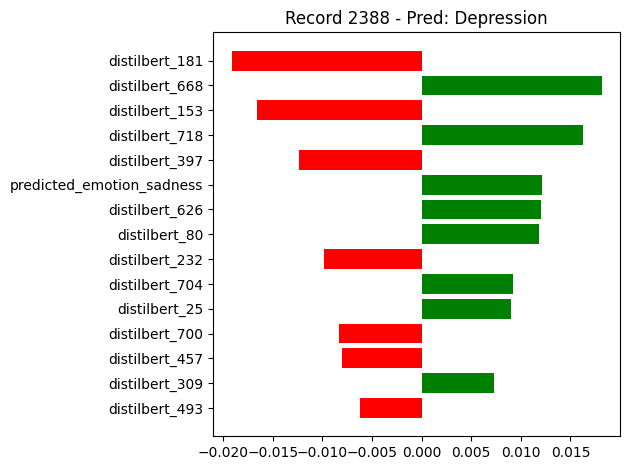


############################################################
RECORD ANALYSIS 22/50 - Dataset Index: 5967
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [+] distilbert_658                           : 0.0327
    [-] distilbert_108                           : -0.0283
    [-] distilbert_363                           : -0.0257
    [+] distilbert_567                           : 0.0221
    [-] distilbert_173                           : -0.0199
    [+] distilbert_711                           : 0.0191
    [+] distilbert_204                           : 0.0176
    [-] distilbert_217                           : -0.0161
    [-] distilbert_496                           : -0.0155
    [+] distilbert_493                           : 0.0152
    [-] distilbert_713                           : -0.0150
    [-] distilbert_484                           : -0.0144
    [-] distil

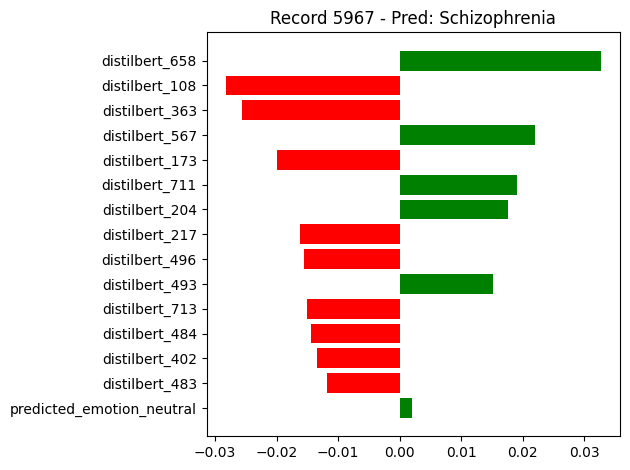


############################################################
RECORD ANALYSIS 23/50 - Dataset Index: 6086
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_597                           : 0.0328
    [+] distilbert_629                           : 0.0302
    [+] distilbert_9                             : 0.0287
    [+] distilbert_347                           : 0.0257
    [+] distilbert_638                           : 0.0214
    [+] distilbert_387                           : 0.0207
    [-] distilbert_645                           : -0.0196
    [-] distilbert_234                           : -0.0181
    [+] distilbert_519                           : 0.0161
    [+] distilbert_445                           : 0.0159
    [+] distilbert_183                           : 0.0147
    [-] distilbert_684                           : -0.0146
    [+] predicted_emotio

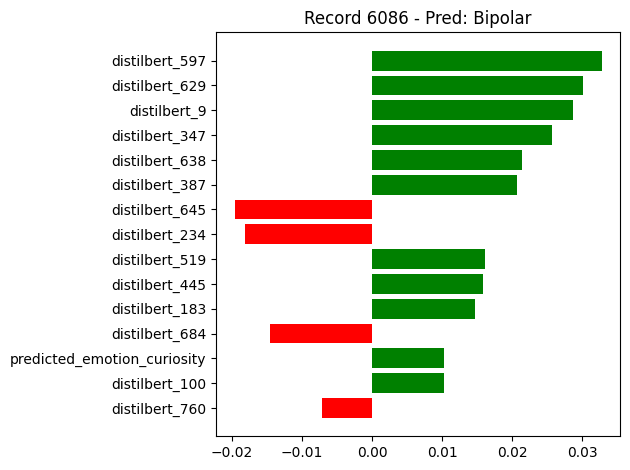


############################################################
RECORD ANALYSIS 24/50 - Dataset Index: 1248
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Anxiety (Class 3)
 -> Top 15 Determinant Features:
    [+] predicted_emotion_nervousness            : 0.0324
    [+] distilbert_107                           : 0.0275
    [+] distilbert_211                           : 0.0249
    [+] distilbert_612                           : 0.0218
    [+] distilbert_110                           : 0.0207
    [+] distilbert_202                           : 0.0186
    [+] distilbert_363                           : 0.0184
    [-] distilbert_681                           : -0.0160
    [+] distilbert_146                           : 0.0158
    [+] distilbert_142                           : 0.0137
    [-] distilbert_182                           : -0.0132
    [+] distilbert_370                           : 0.0123
    [-] distilbert_287   

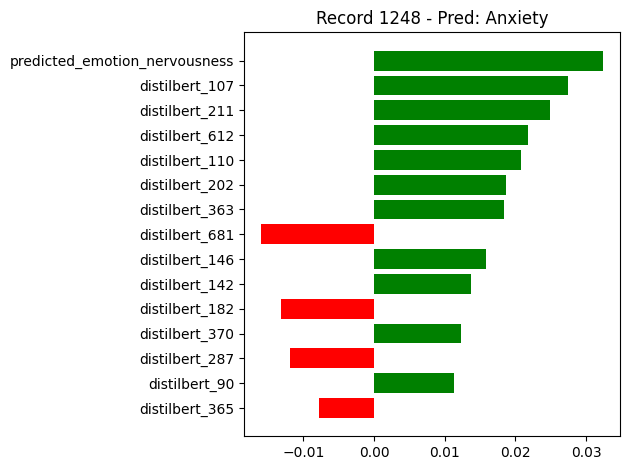


############################################################
RECORD ANALYSIS 25/50 - Dataset Index: 1365
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_9                             : 0.0250
    [+] distilbert_347                           : 0.0238
    [+] distilbert_519                           : 0.0228
    [+] distilbert_339                           : 0.0216
    [+] distilbert_397                           : 0.0207
    [+] distilbert_541                           : 0.0198
    [+] distilbert_503                           : 0.0197
    [-] distilbert_493                           : -0.0194
    [+] distilbert_638                           : 0.0179
    [-] distilbert_90                            : -0.0173
    [-] distilbert_107                           : -0.0151
    [+] distilbert_482                           : 0.0144
    [+] distilbert_694  

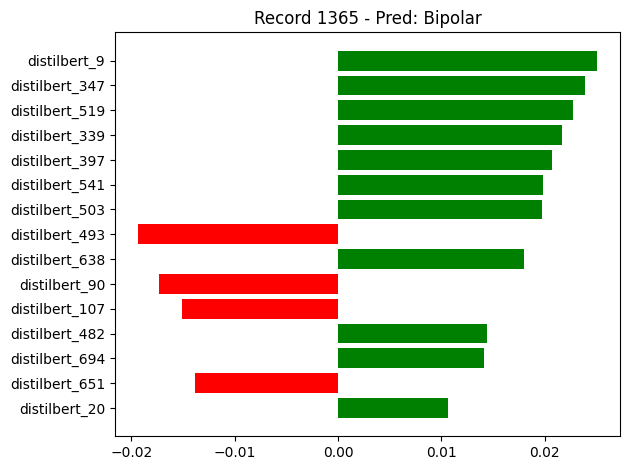


############################################################
RECORD ANALYSIS 26/50 - Dataset Index: 3026
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [+] distilbert_645                           : 0.0177
    [-] distilbert_24                            : -0.0175
    [+] predicted_emotion_sadness                : 0.0167
    [+] distilbert_286                           : 0.0167
    [-] distilbert_598                           : -0.0159
    [+] toxicity_score_log                       : 0.0154
    [+] distilbert_696                           : 0.0145
    [+] distilbert_718                           : 0.0134
    [-] distilbert_101                           : -0.0128
    [+] distilbert_704                           : 0.0121
    [-] distilbert_322                           : -0.0112
    [+] distilbert_59                            : 0.0105
    [-] distilbert_3

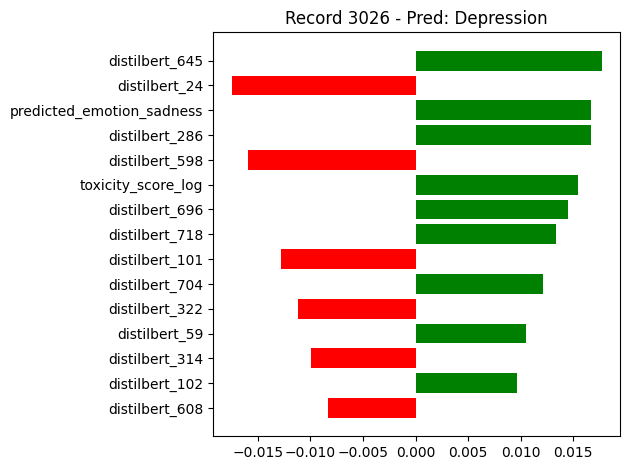


############################################################
RECORD ANALYSIS 27/50 - Dataset Index: 3272
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [+] distilbert_192                           : 0.0225
    [-] distilbert_173                           : -0.0202
    [+] distilbert_133                           : 0.0197
    [+] distilbert_547                           : 0.0190
    [-] distilbert_402                           : -0.0186
    [-] distilbert_301                           : -0.0186
    [+] distilbert_574                           : 0.0185
    [+] distilbert_47                            : 0.0178
    [-] distilbert_48                            : -0.0166
    [-] distilbert_108                           : -0.0151
    [+] distilbert_430                           : 0.0134
    [+] distilbert_215                           : 0.0130
    [-] distilbe

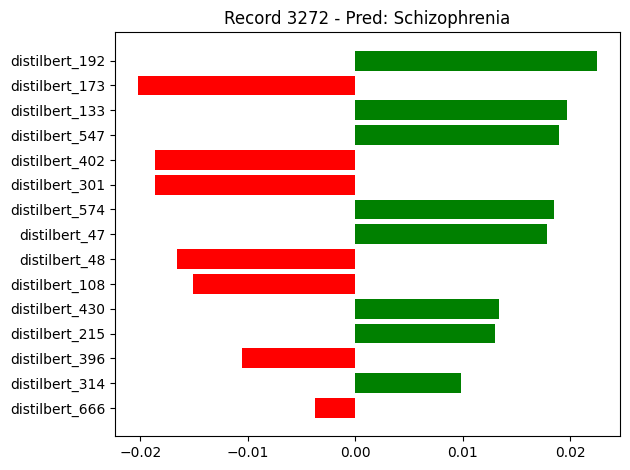


############################################################
RECORD ANALYSIS 28/50 - Dataset Index: 2589
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [-] distilbert_432                           : -0.0192
    [+] distilbert_286                           : 0.0191
    [+] distilbert_438                           : 0.0139
    [+] distilbert_49                            : 0.0128
    [+] distilbert_701                           : 0.0118
    [-] distilbert_284                           : -0.0102
    [+] distilbert_33                            : 0.0098
    [+] distilbert_151                           : 0.0096
    [+] distilbert_108                           : 0.0092
    [-] distilbert_549                           : -0.0086
    [+] predicted_emotion_disappointment         : 0.0085
    [+] distilbert_345                           : 0.0084
    [-] distilbert_31

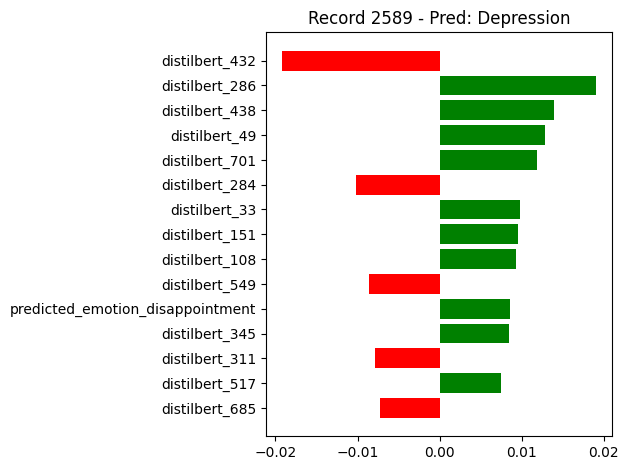


############################################################
RECORD ANALYSIS 29/50 - Dataset Index: 6624
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_304                           : 0.0304
    [-] distilbert_372                           : -0.0220
    [+] distilbert_311                           : 0.0211
    [-] distilbert_604                           : -0.0201
    [-] distilbert_597                           : -0.0194
    [-] distilbert_508                           : -0.0191
    [+] distilbert_476                           : 0.0173
    [+] distilbert_81                            : 0.0153
    [+] distilbert_647                           : 0.0139
    [+] distilbert_331                           : 0.0137
    [-] distilbert_550                           : -0.0131
    [+] distilbert_598                           : 0.0121
    [+] distilbert_590    

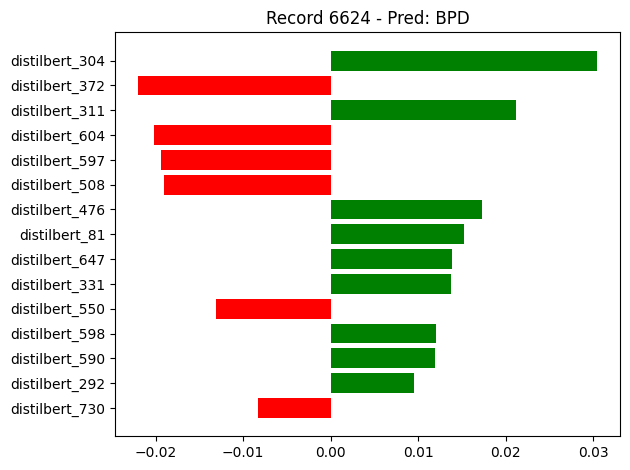


############################################################
RECORD ANALYSIS 30/50 - Dataset Index: 2351
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_396                           : 0.0228
    [+] distilbert_311                           : 0.0219
    [-] distilbert_93                            : -0.0216
    [-] distilbert_372                           : -0.0190
    [+] distilbert_614                           : 0.0172
    [+] distilbert_660                           : 0.0171
    [+] distilbert_331                           : 0.0159
    [+] distilbert_759                           : 0.0154
    [+] distilbert_646                           : 0.0133
    [-] distilbert_482                           : -0.0120
    [-] distilbert_547                           : -0.0118
    [+] distilbert_392                           : 0.0108
    [+] distilbert_465     

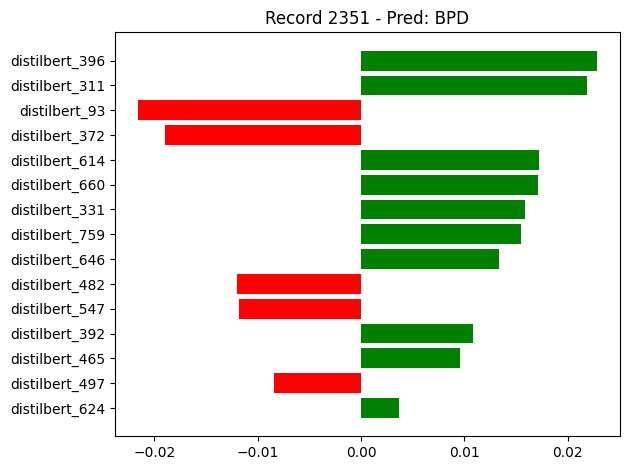


############################################################
RECORD ANALYSIS 31/50 - Dataset Index: 7026
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_155                           : 0.0346
    [+] distilbert_551                           : 0.0259
    [+] distilbert_396                           : 0.0254
    [-] distilbert_756                           : -0.0212
    [-] distilbert_757                           : -0.0163
    [+] distilbert_199                           : 0.0163
    [-] distilbert_266                           : -0.0162
    [+] distilbert_179                           : 0.0159
    [+] distilbert_759                           : 0.0158
    [-] distilbert_95                            : -0.0115
    [-] distilbert_443                           : -0.0114
    [-] distilbert_270                           : -0.0109
    [-] distilbert_663   

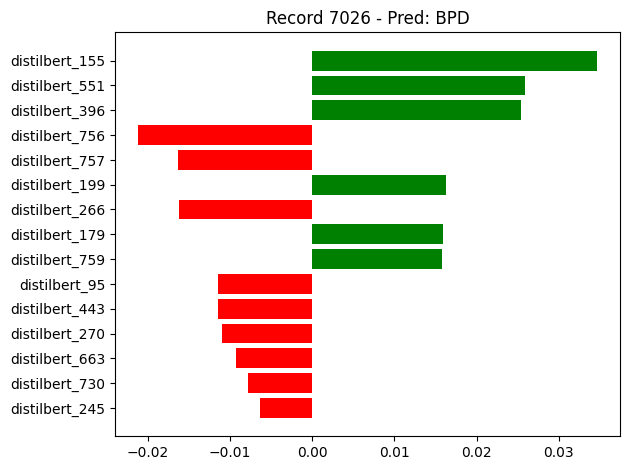


############################################################
RECORD ANALYSIS 32/50 - Dataset Index: 3285
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_397                           : 0.0244
    [-] distilbert_582                           : -0.0241
    [+] distilbert_541                           : 0.0238
    [+] distilbert_544                           : 0.0219
    [+] distilbert_282                           : 0.0217
    [-] distilbert_164                           : -0.0217
    [+] distilbert_9                             : 0.0201
    [+] distilbert_638                           : 0.0197
    [-] distilbert_645                           : -0.0188
    [+] distilbert_503                           : 0.0174
    [+] distilbert_72                            : 0.0148
    [+] distilbert_101                           : 0.0141
    [-] distilbert_80   

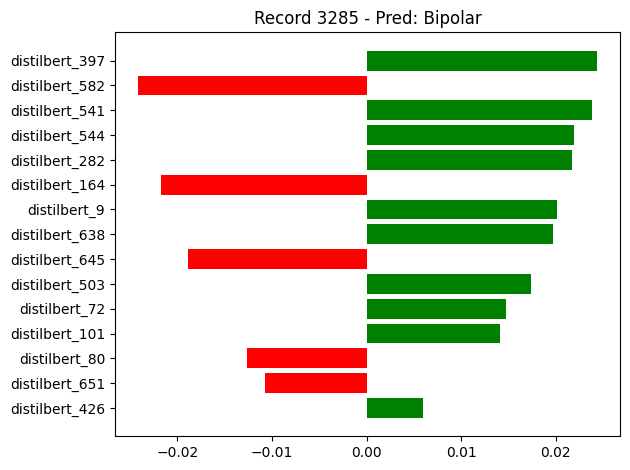


############################################################
RECORD ANALYSIS 33/50 - Dataset Index: 159
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [-] distilbert_363                           : -0.0293
    [-] distilbert_484                           : -0.0247
    [+] distilbert_98                            : 0.0212
    [+] distilbert_127                           : 0.0211
    [-] distilbert_396                           : -0.0206
    [-] distilbert_108                           : -0.0179
    [-] distilbert_107                           : -0.0173
    [-] distilbert_476                           : -0.0165
    [+] distilbert_181                           : 0.0160
    [-] distilbert_173                           : -0.0157
    [-] distilbert_75                            : -0.0156
    [+] distilbert_462                           : 0.0150
    [+] distil

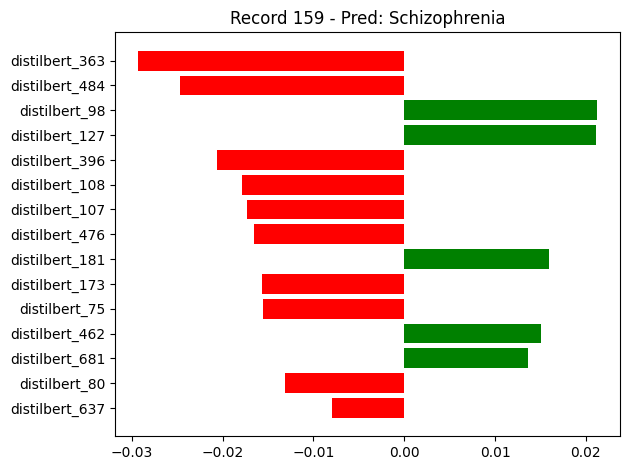


############################################################
RECORD ANALYSIS 34/50 - Dataset Index: 6515
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [-] distilbert_363                           : -0.0238
    [+] distilbert_314                           : 0.0204
    [+] distilbert_62                            : 0.0196
    [-] distilbert_713                           : -0.0179
    [+] distilbert_133                           : 0.0175
    [-] distilbert_590                           : -0.0167
    [-] distilbert_347                           : -0.0164
    [-] distilbert_597                           : -0.0156
    [+] distilbert_485                           : 0.0140
    [+] distilbert_599                           : 0.0136
    [-] distilbert_297                           : -0.0118
    [-] distilbert_166                           : -0.0117
    [+] distil

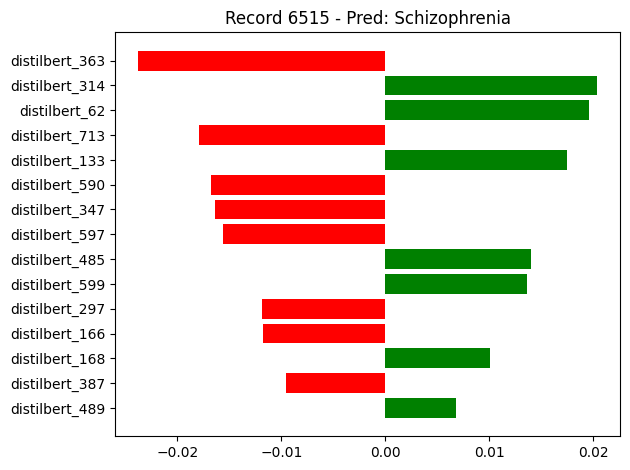


############################################################
RECORD ANALYSIS 35/50 - Dataset Index: 7148
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Bipolar (Class 1)
 -> Top 15 Determinant Features:
    [+] distilbert_544                           : 0.0284
    [+] distilbert_691                           : 0.0274
    [+] distilbert_387                           : 0.0246
    [-] distilbert_453                           : -0.0236
    [-] distilbert_623                           : -0.0234
    [+] distilbert_9                             : 0.0230
    [+] distilbert_369                           : 0.0225
    [-] distilbert_493                           : -0.0193
    [-] distilbert_637                           : -0.0171
    [+] distilbert_240                           : 0.0161
    [-] distilbert_42                            : -0.0158
    [+] distilbert_671                           : 0.0142
    [-] distilbert_311

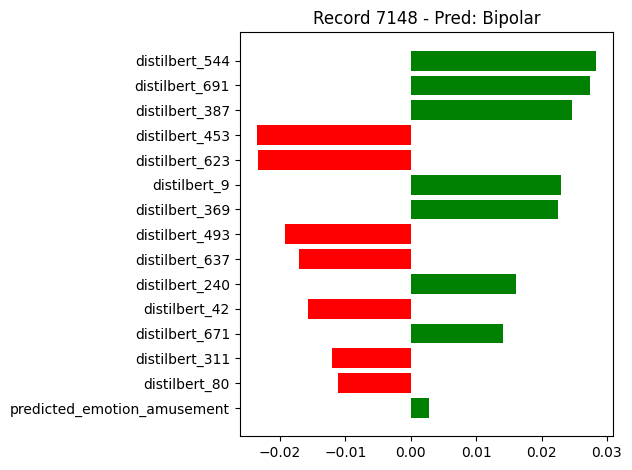


############################################################
RECORD ANALYSIS 36/50 - Dataset Index: 739
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [+] distilbert_6                             : 0.0277
    [-] distilbert_348                           : -0.0263
    [+] distilbert_711                           : 0.0210
    [-] distilbert_363                           : -0.0203
    [-] distilbert_297                           : -0.0197
    [+] distilbert_223                           : 0.0197
    [-] distilbert_597                           : -0.0184
    [+] distilbert_754                           : 0.0177
    [-] distilbert_495                           : -0.0146
    [-] distilbert_301                           : -0.0136
    [+] distilbert_744                           : 0.0132
    [-] distilbert_226                           : -0.0131
    [+] distilb

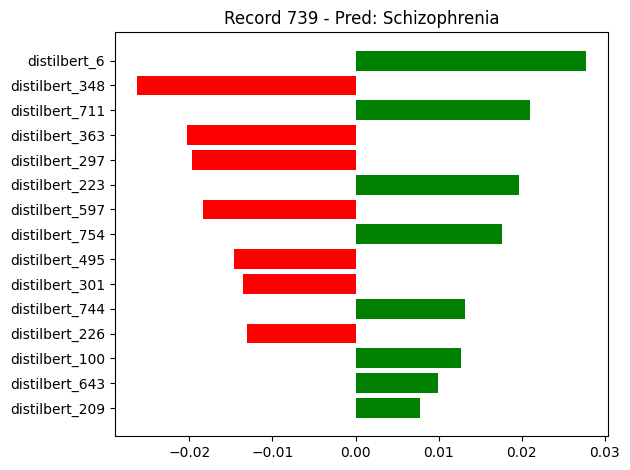


############################################################
RECORD ANALYSIS 37/50 - Dataset Index: 317
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [+] distilbert_133                           : 0.0268
    [-] distilbert_80                            : -0.0203
    [+] distilbert_755                           : 0.0197
    [+] distilbert_254                           : 0.0183
    [-] distilbert_396                           : -0.0178
    [+] distilbert_711                           : 0.0157
    [-] distilbert_713                           : -0.0156
    [-] distilbert_448                           : -0.0148
    [+] distilbert_76                            : 0.0143
    [+] distilbert_67                            : 0.0142
    [-] distilbert_184                           : -0.0138
    [+] distilbert_513                           : 0.0136
    [+] distilber

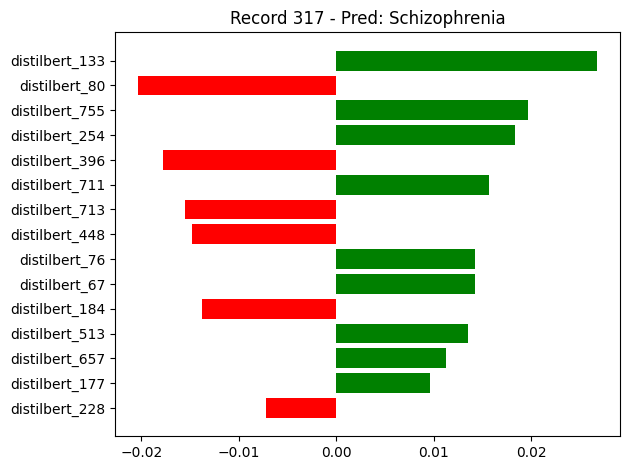


############################################################
RECORD ANALYSIS 38/50 - Dataset Index: 5317
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [-] distilbert_705                           : -0.0216
    [+] distilbert_645                           : 0.0193
    [+] distilbert_704                           : 0.0175
    [-] distilbert_190                           : -0.0145
    [-] distilbert_493                           : -0.0138
    [+] distilbert_61                            : 0.0125
    [-] distilbert_586                           : -0.0122
    [+] distilbert_33                            : 0.0119
    [-] distilbert_218                           : -0.0109
    [-] distilbert_634                           : -0.0103
    [-] distilbert_397                           : -0.0099
    [-] distilbert_235                           : -0.0095
    [-] distilbe

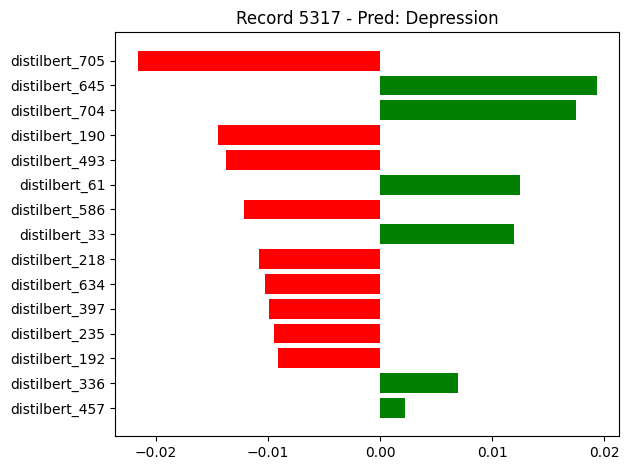


############################################################
RECORD ANALYSIS 39/50 - Dataset Index: 120
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [-] distilbert_516                           : -0.0299
    [+] distilbert_395                           : 0.0253
    [+] distilbert_647                           : 0.0233
    [+] distilbert_484                           : 0.0209
    [-] distilbert_462                           : -0.0179
    [-] distilbert_372                           : -0.0177
    [-] distilbert_547                           : -0.0169
    [-] distilbert_334                           : -0.0160
    [+] distilbert_619                           : 0.0145
    [-] distilbert_763                           : -0.0141
    [+] distilbert_645                           : 0.0124
    [-] distilbert_604                           : -0.0109
    [+] distilbert_56    

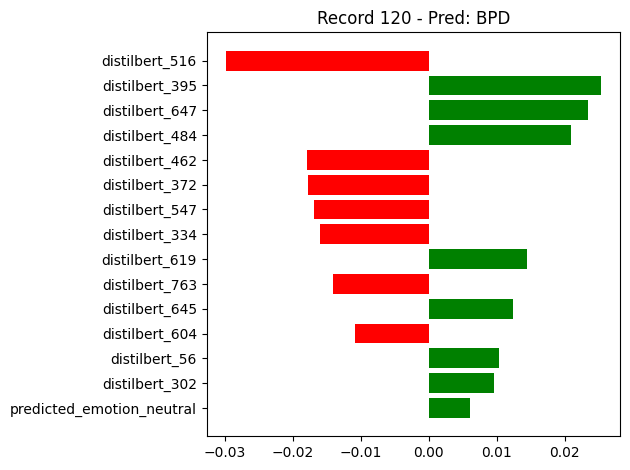


############################################################
RECORD ANALYSIS 40/50 - Dataset Index: 522
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Anxiety (Class 3)
 -> Top 15 Determinant Features:
    [+] predicted_emotion_nervousness            : 0.0317
    [+] distilbert_354                           : 0.0293
    [-] distilbert_544                           : -0.0245
    [+] distilbert_234                           : 0.0245
    [-] distilbert_204                           : -0.0201
    [+] distilbert_363                           : 0.0188
    [-] distilbert_681                           : -0.0188
    [-] distilbert_562                           : -0.0183
    [+] distilbert_290                           : 0.0176
    [+] distilbert_146                           : 0.0170
    [-] distilbert_379                           : -0.0168
    [+] distilbert_685                           : 0.0150
    [+] distilbert_22  

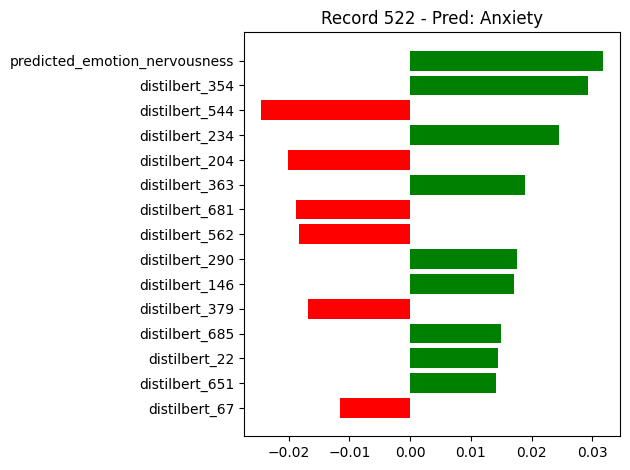


############################################################
RECORD ANALYSIS 41/50 - Dataset Index: 3163
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [-] distilbert_181                           : -0.0248
    [+] predicted_emotion_disappointment         : 0.0232
    [+] distilbert_645                           : 0.0164
    [+] distilbert_438                           : 0.0157
    [+] distilbert_367                           : 0.0148
    [-] distilbert_705                           : -0.0129
    [-] distilbert_689                           : -0.0129
    [-] distilbert_399                           : -0.0121
    [-] distilbert_493                           : -0.0106
    [+] distilbert_29                            : 0.0090
    [-] distilbert_176                           : -0.0090
    [-] distilbert_708                           : -0.0089
    [-] distilber

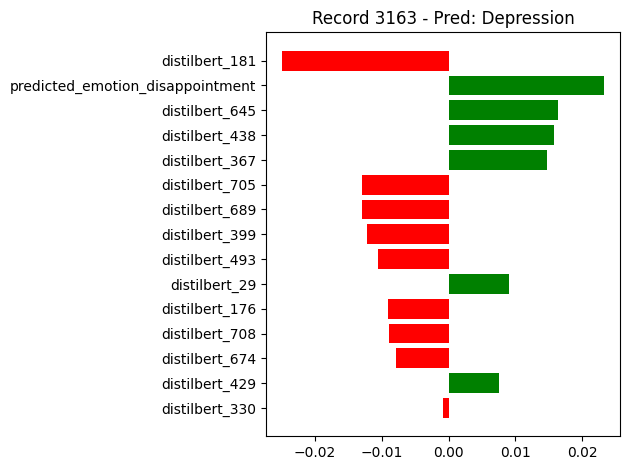


############################################################
RECORD ANALYSIS 42/50 - Dataset Index: 2060
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [-] distilbert_83                            : -0.0236
    [-] distilbert_93                            : -0.0235
    [-] distilbert_567                           : -0.0219
    [+] distilbert_311                           : 0.0191
    [-] distilbert_462                           : -0.0178
    [-] distilbert_66                            : -0.0167
    [-] distilbert_594                           : -0.0137
    [-] distilbert_469                           : -0.0131
    [+] distilbert_609                           : 0.0127
    [+] distilbert_30                            : 0.0112
    [+] distilbert_301                           : 0.0101
    [-] toxicity_score_log                       : -0.0098
    [+] distilbert_67  

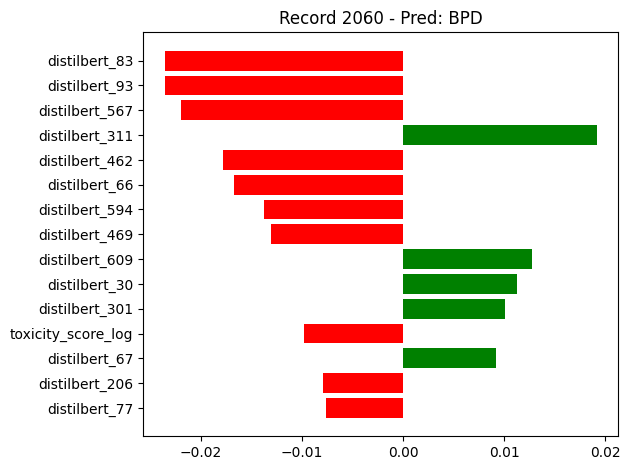


############################################################
RECORD ANALYSIS 43/50 - Dataset Index: 3456
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [+] distilbert_286                           : 0.0216
    [-] distilbert_198                           : -0.0165
    [+] distilbert_151                           : 0.0154
    [+] distilbert_645                           : 0.0144
    [-] distilbert_424                           : -0.0140
    [-] distilbert_503                           : -0.0134
    [-] distilbert_214                           : -0.0132
    [-] distilbert_767                           : -0.0122
    [+] distilbert_540                           : 0.0120
    [+] distilbert_18                            : 0.0119
    [+] distilbert_668                           : 0.0115
    [-] distilbert_397                           : -0.0097
    [+] distilbert

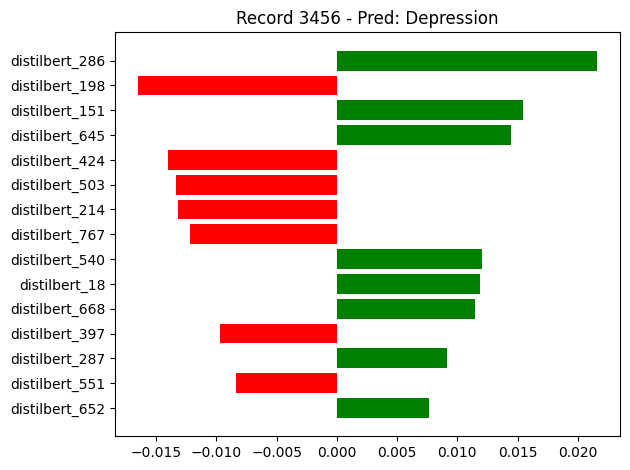


############################################################
RECORD ANALYSIS 44/50 - Dataset Index: 6467
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Anxiety (Class 3)
 -> Top 15 Determinant Features:
    [-] distilbert_544                           : -0.0246
    [-] distilbert_157                           : -0.0235
    [-] distilbert_691                           : -0.0209
    [+] distilbert_297                           : 0.0181
    [-] distilbert_72                            : -0.0164
    [-] distilbert_275                           : -0.0158
    [-] distilbert_519                           : -0.0144
    [+] distilbert_370                           : 0.0130
    [+] distilbert_290                           : 0.0121
    [+] distilbert_363                           : 0.0118
    [-] distilbert_182                           : -0.0114
    [+] predicted_emotion_fear                   : 0.0106
    [+] distilbert_1

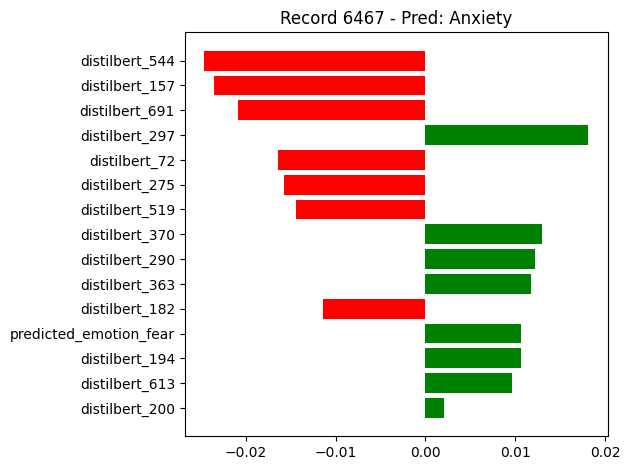


############################################################
RECORD ANALYSIS 45/50 - Dataset Index: 3470
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Schizophrenia (Class 4)
 -> Top 15 Determinant Features:
    [-] distilbert_348                           : -0.0295
    [+] distilbert_658                           : 0.0292
    [-] distilbert_217                           : -0.0214
    [-] distilbert_173                           : -0.0211
    [-] distilbert_448                           : -0.0192
    [-] distilbert_749                           : -0.0176
    [+] distilbert_628                           : 0.0158
    [-] distilbert_701                           : -0.0152
    [+] distilbert_639                           : 0.0141
    [-] distilbert_304                           : -0.0137
    [-] distilbert_48                            : -0.0124
    [-] distilbert_389                           : -0.0122
    [-] dist

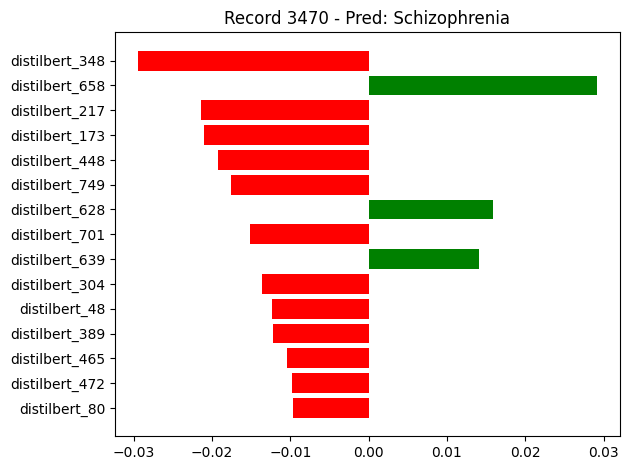


############################################################
RECORD ANALYSIS 46/50 - Dataset Index: 7331
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [+] distilbert_484                           : 0.0214
    [-] distilbert_462                           : -0.0214
    [-] distilbert_83                            : -0.0211
    [-] distilbert_93                            : -0.0193
    [-] distilbert_703                           : -0.0191
    [+] distilbert_614                           : 0.0186
    [+] distilbert_304                           : 0.0184
    [-] distilbert_264                           : -0.0169
    [-] distilbert_256                           : -0.0151
    [+] distilbert_64                            : 0.0146
    [+] distilbert_498                           : 0.0137
    [-] distilbert_334                           : -0.0130
    [+] distilbert_182  

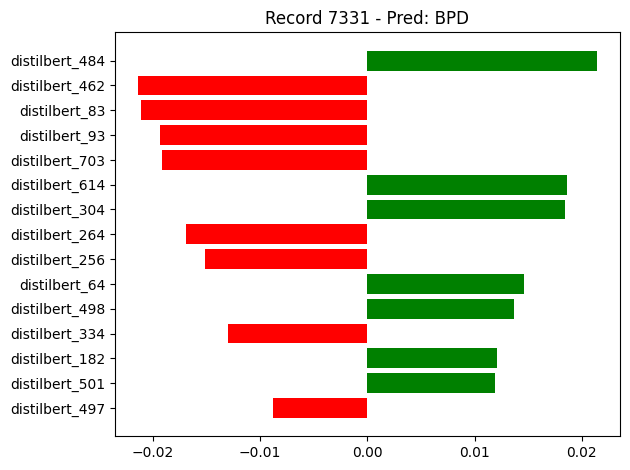


############################################################
RECORD ANALYSIS 47/50 - Dataset Index: 4692
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Anxiety (Class 3)
 -> Top 15 Determinant Features:
    [+] distilbert_107                           : 0.0332
    [-] distilbert_544                           : -0.0276
    [-] distilbert_379                           : -0.0260
    [-] distilbert_157                           : -0.0211
    [-] distilbert_681                           : -0.0210
    [+] distilbert_612                           : 0.0178
    [+] distilbert_354                           : 0.0169
    [-] distilbert_72                            : -0.0161
    [+] distilbert_685                           : 0.0146
    [+] predicted_emotion_fear                   : 0.0126
    [+] distilbert_521                           : 0.0123
    [-] distilbert_322                           : -0.0115
    [-] distilbert_28

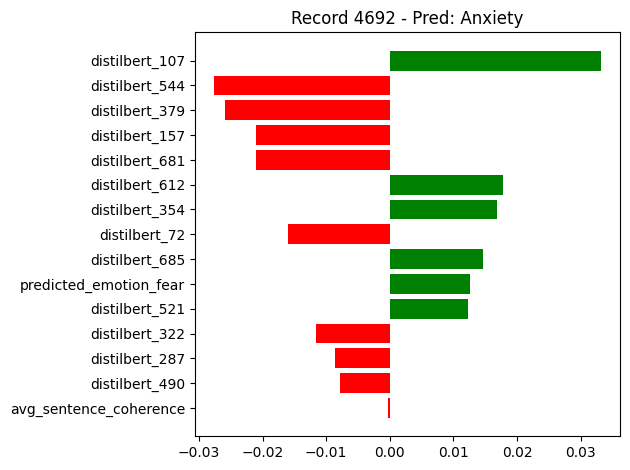


############################################################
RECORD ANALYSIS 48/50 - Dataset Index: 7901
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [-] distilbert_181                           : -0.0226
    [-] distilbert_632                           : -0.0202
    [+] distilbert_718                           : 0.0171
    [-] distilbert_0                             : -0.0141
    [+] distilbert_25                            : 0.0125
    [+] distilbert_18                            : 0.0123
    [+] distilbert_286                           : 0.0123
    [+] distilbert_61                            : 0.0116
    [+] distilbert_448                           : 0.0114
    [+] distilbert_677                           : 0.0099
    [+] distilbert_623                           : 0.0098
    [+] distilbert_42                            : 0.0093
    [-] distilbert_28

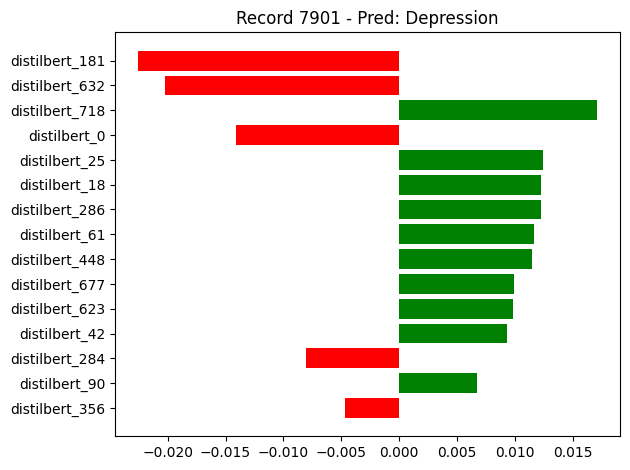


############################################################
RECORD ANALYSIS 49/50 - Dataset Index: 6665
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: BPD (Class 0)
 -> Top 15 Determinant Features:
    [-] distilbert_516                           : -0.0299
    [-] distilbert_703                           : -0.0235
    [+] distilbert_311                           : 0.0211
    [+] distilbert_510                           : 0.0205
    [+] distilbert_765                           : 0.0191
    [-] distilbert_95                            : -0.0168
    [-] distilbert_233                           : -0.0149
    [-] distilbert_234                           : -0.0147
    [+] distilbert_182                           : 0.0146
    [+] distilbert_499                           : 0.0124
    [+] distilbert_58                            : 0.0116
    [-] distilbert_323                           : -0.0110
    [+] distilbert_598   

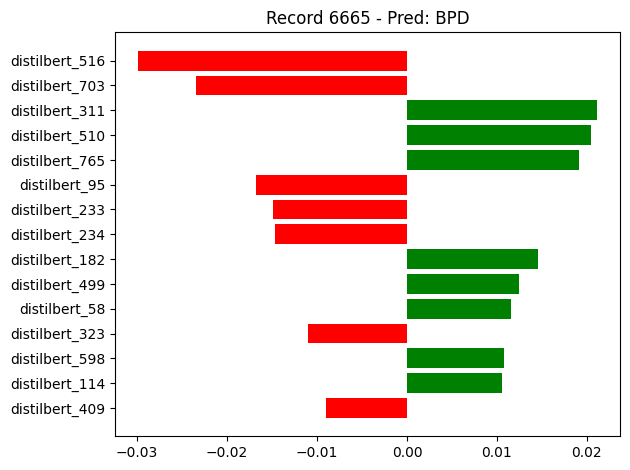


############################################################
RECORD ANALYSIS 50/50 - Dataset Index: 7082
############################################################
 -> Calculating LIME perturbations...
 -> Model Predicted: Depression (Class 2)
 -> Top 15 Determinant Features:
    [-] distilbert_181                           : -0.0193
    [+] distilbert_286                           : 0.0186
    [+] distilbert_718                           : 0.0157
    [+] distilbert_585                           : 0.0150
    [+] distilbert_21                            : 0.0135
    [+] distilbert_507                           : 0.0131
    [-] distilbert_432                           : -0.0119
    [+] distilbert_29                            : 0.0117
    [+] distilbert_668                           : 0.0113
    [-] distilbert_440                           : -0.0110
    [-] distilbert_600                           : -0.0104
    [+] distilbert_474                           : 0.0103
    [-] distilbert_6

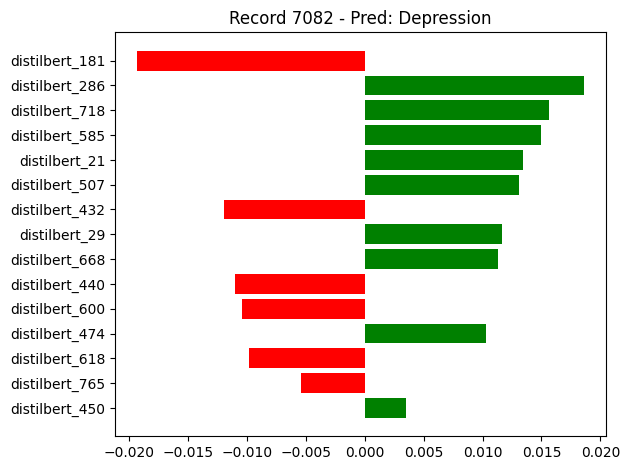


Analysis complete.


In [3]:
# Define Class Names (Try to get from config, otherwise default to 0-4)
class_names = config.get('class_names', [0, 1, 2, 3, 4])
class_names = [str(c) for c in class_names]

def predict_fn(data_numpy):
    # Convert numpy array to tensor for PyTorch model
    data_tensor = torch.tensor(data_numpy).float().to(device)
    with torch.no_grad():
        logits = model(data_tensor)
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

print("Initializing Explainer (using CSV feature names)...")
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,     
    feature_names=feature_names,   
    class_names=class_names,          
    mode='classification',            
    discretize_continuous=False       
)

# EXECUTION ON MULTIPLE RECORDS (50 RECORDS)
indices_to_explain = np.random.choice(X_test_scaled.shape[0], 50, replace=False)

print(f"\n[INFO] Starting analysis on {len(indices_to_explain)} random samples: {indices_to_explain}")

for i, idx in enumerate(indices_to_explain):
    print("\n" + "#"*60)
    print(f"RECORD ANALYSIS {i+1}/50 - Dataset Index: {idx}")
    print("#"*60)

    sample = X_test_scaled[idx]

    # Calculate LIME
    print(" -> Calculating LIME perturbations...")
    exp = explainer.explain_instance(
        data_row=sample, 
        predict_fn=predict_fn, 
        num_features=15, 
        top_labels=1
    )
    
    # Retrieve prediction info
    predicted_label = exp.top_labels[0]
    predicted_name = class_names[predicted_label]
    
    print(f" -> Model Predicted: {predicted_name} (Class {predicted_label})")
    print(" -> Top 15 Determinant Features:")
    
    # Print list 
    top_features = exp.as_list(label=predicted_label)
    for feat, weight in top_features:
        sign = "[+]" if weight > 0 else "[-]"
        print(f"    {sign} {feat:<40} : {weight:.4f}")
        
    # Show plot
    print(" -> Generating plot...")
    fig = exp.as_pyplot_figure(label=predicted_label)
    plt.title(f"Record {idx} - Pred: {predicted_name}")
    plt.tight_layout()
    plt.show()

print("\nAnalysis complete.")

### Shap

Calculating K-Means
Calculating SHAP DeepExplainer


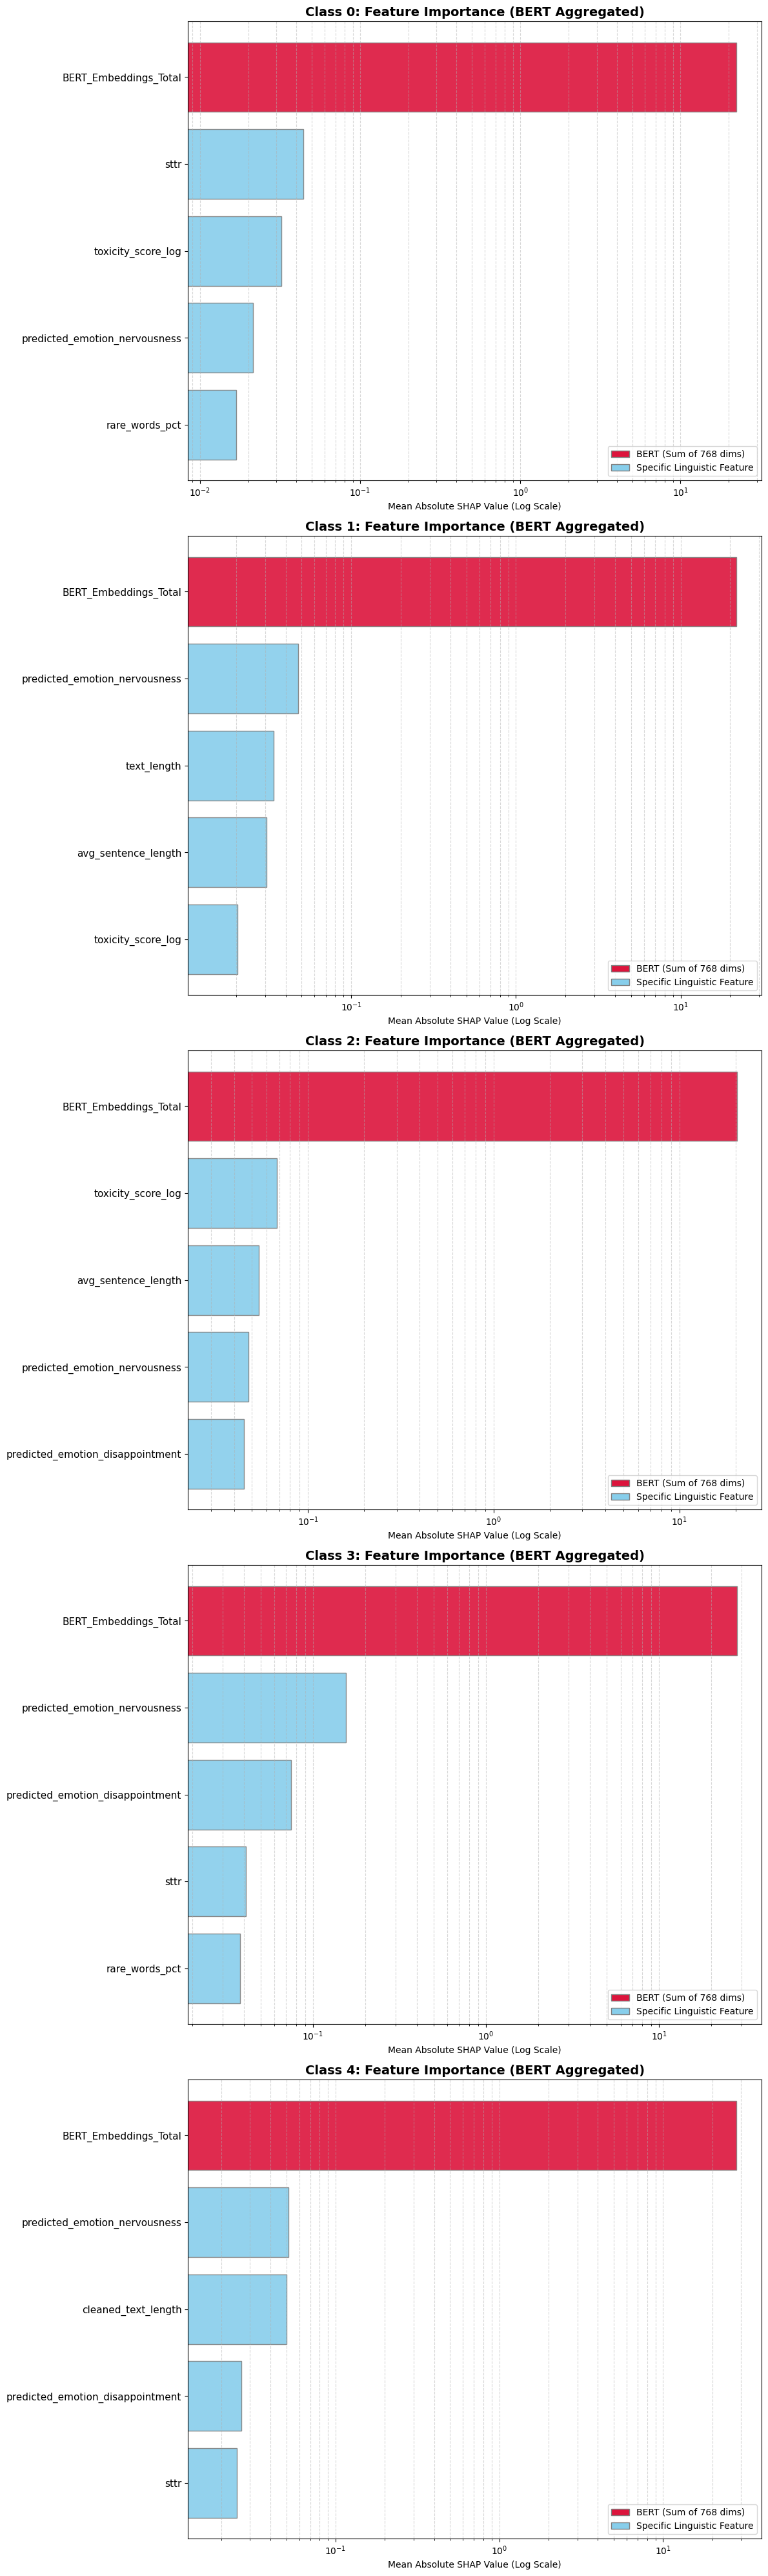

In [4]:
# SHAP CONFIGURATION & CALCULATION

print("Calculating K-Means")
# Summarize training data to 150 weighted centroids (speeds up DeepExplainer)
background = shap.kmeans(X_train_scaled, 150).data
background_tensor = torch.tensor(background).float().to(device)

# Select 50 random samples from test set to explain predictions
idx = np.random.choice(X_test_scaled.shape[0], 50, replace=False)
X_explain_tensor = torch.tensor(X_test_scaled[idx]).float().to(device)

print("Calculating SHAP DeepExplainer")
# Initialize Explainer and compute SHAP values
explainer = shap.DeepExplainer(model, background_tensor)
shap_values = explainer.shap_values(X_explain_tensor)

# AGGREGATED FEATURE IMPORTANCE PLOTTING (BERT + EXTRA FEATURES)

num_classes = 5
n_top_features = 5  # Top N features to show per class

# Create figure
fig, axes = plt.subplots(nrows=num_classes, ncols=1, figsize=(12, 8 * num_classes))
if num_classes == 1: axes = [axes]

# Define keywords for MANUAL features
# Logic: If a feature name does NOT contain these words, it is treated as a BERT embedding dimension.
extra_keywords = [
    "length", "sttr", "coherence", "toxicity", "rare", "polarity", 
    "emotion", "subjectivity", "readability", "pos_", "dep_"
]


# PLOTTING LOOP (per class)
for i in range(num_classes):
    ax = axes[i]
    
    # --- Extract SHAP Values ---
    # Handle list vs array output formats from SHAP
    if isinstance(shap_values, list):
        vals = np.abs(shap_values[i])
    else:
        if len(shap_values.shape) == 3: 
            vals = np.abs(shap_values[:, :, i])
        else:
            vals = np.abs(shap_values)

    # Validate dimensions against feature names
    num_features_found = vals.shape[1]
    expected_features = len(feature_names)
    
    # Use real names if dimensions match, otherwise use generic names
    if num_features_found == expected_features:
        current_names = feature_names
    else:
        print(f"Dimension mismatch in Class {i}: using generic indices.")
        current_names = [f"Feat_{k}" for k in range(num_features_found)]

    # --- CALCULATE IMPORTANCE ---
    # Global mean importance (shape: 805,)
    mean_imp = np.mean(vals, axis=0)
    
    # --- AGGREGATION ---
    bert_aggregated_value = 0.0
    plot_names = []
    plot_values = []
    
    for idx, name in enumerate(current_names):
        # Check if feature is "Extra" (Manual) or "BERT" (Embedding)
        is_extra = any(key in name.lower() for key in extra_keywords)
        
        if is_extra:
            # If it's an extra feature, keep it separate
            plot_names.append(name)
            plot_values.append(mean_imp[idx])
        else:
            # If it's NOT extra (it's a BERT dimension), sum it up
            bert_aggregated_value += mean_imp[idx]
            
    # Add the aggregated BERT super-feature to the list
    plot_names.append("BERT_Embeddings_Total")
    plot_values.append(bert_aggregated_value)
    
    # Convert to numpy array for easier sorting
    plot_names = np.array(plot_names)
    plot_values = np.array(plot_values)
    
    # --- SORTING AND SELECTION ---
    # Select the Top N features among (BERT Total + Extra Features)
    # n_show ensures we don't crash if we have fewer features than n_top_features
    n_show = min(n_top_features, len(plot_values))
    
    idx_sort = np.argsort(plot_values)[-n_show:] # Indices of the highest values
    
    sorted_values = plot_values[idx_sort]
    sorted_names = plot_names[idx_sort]
    
    # --- PLOTTING ---
    y_pos = np.arange(len(sorted_values))
    
    # Color coding: Crimson for BERT, Skyblue for other features
    bar_colors = ['crimson' if "BERT_Embeddings" in name else 'skyblue' for name in sorted_names]
    
    ax.barh(y_pos, sorted_values, color=bar_colors, edgecolor='gray', alpha=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_names, fontsize=11, fontweight='medium')
    
    # Logarithmic scale (Essential because BERT sum will be much larger)
    ax.set_xscale('log')
    
    # Dynamic left limit to improve aesthetics (prevents invisible bars)
    if len(sorted_values) > 0 and np.max(sorted_values) > 0:
        non_zero = sorted_values[sorted_values > 0]
        if len(non_zero) > 0:
            ax.set_xlim(left=np.min(non_zero) * 0.5)
            
    ax.set_title(f"Class {i}: Feature Importance (BERT Aggregated)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Mean Absolute SHAP Value (Log Scale)", fontsize=10)
    
    # Legend
    legend_elements = [
        Patch(facecolor='crimson', edgecolor='gray', label='BERT (Sum of 768 dims)'),
        Patch(facecolor='skyblue', edgecolor='gray', label='Specific Linguistic Feature')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    ax.grid(True, which="both", axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()